<a href="https://colab.research.google.com/github/Mutasar/Eksperimen_MSML_Mutasar/blob/main/Template_Eksperimen_MSML_Mutasar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here

# Import library untuk manipulasi data
import pandas as pd
import numpy as np

# Import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Atur style visualisasi bawaan (opsional)
sns.set_theme(style="whitegrid")

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# 1. Menghubungkan Google Drive ke Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Type your code here

file_path = '/content/drive/MyDrive/Eksperimen_MSML-20260508T060229Z-3-001/Eksperimen_MSML/day.csv'

# 4. Memuat dataset menggunakan pandas
df = pd.read_csv(file_path)

# 5. Menampilkan 5 baris pertama untuk memastikan data berhasil dimuat
print("Lima baris pertama dataset:")
display(df.head())

# 6. Menampilkan informasi dasar dataset (tipe data dan jumlah kolom/baris)
print("\nInformasi Dataset:")
df.info()

Lima baris pertama dataset:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

=== EXPLORATORY DATA ANALYSIS (EDA) ===


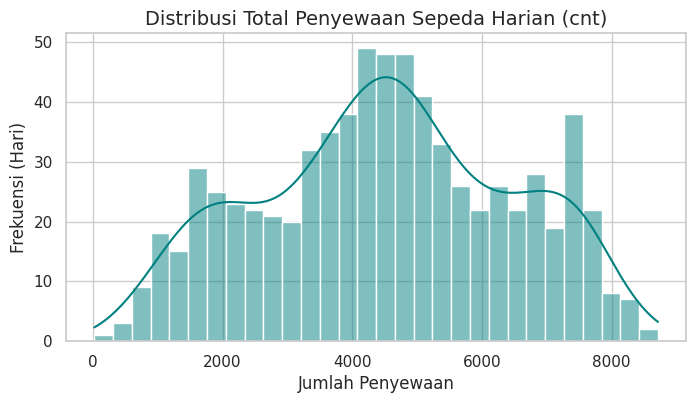

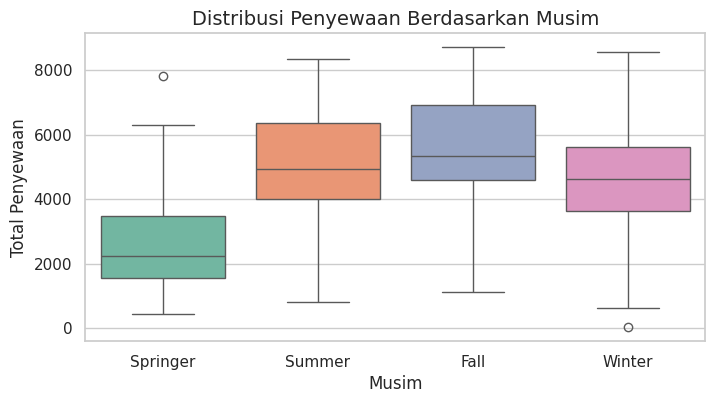

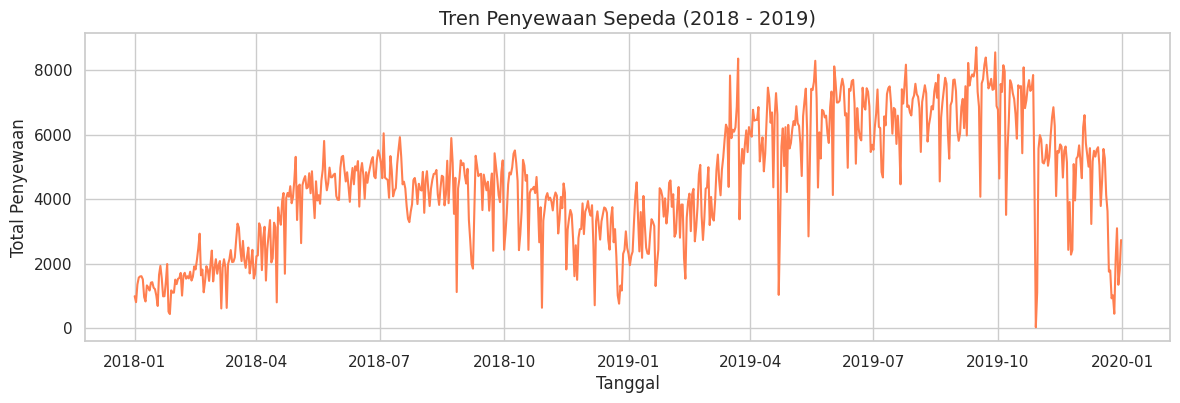

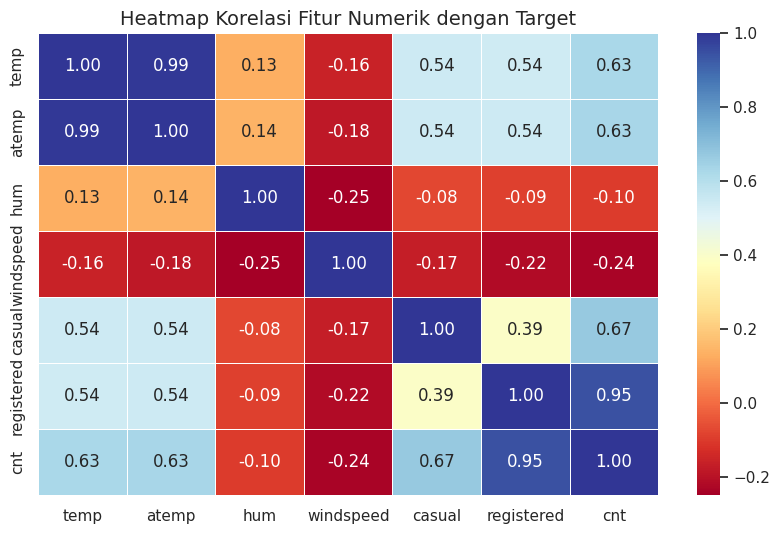

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Atur gaya grafik agar lebih rapi
sns.set_theme(style="whitegrid")

# Pastikan kolom dteday bertipe datetime untuk analisis tren waktu
df['dteday'] = pd.to_datetime(df['dteday'], format='%d-%m-%Y', errors='coerce')

print("=== EXPLORATORY DATA ANALYSIS (EDA) ===")

# 1. Distribusi Target Variabel (Total Penyewaan)
plt.figure(figsize=(8, 4))
sns.histplot(df['cnt'], bins=30, kde=True, color='teal')
plt.title('Distribusi Total Penyewaan Sepeda Harian (cnt)', fontsize=14)
plt.xlabel('Jumlah Penyewaan')
plt.ylabel('Frekuensi (Hari)')
plt.show()

# 2. Penyewaan Berdasarkan Musim (Boxplot)
plt.figure(figsize=(8, 4))
sns.boxplot(x='season', y='cnt', data=df, palette='Set2', hue='season', legend=False)
plt.title('Distribusi Penyewaan Berdasarkan Musim', fontsize=14)
plt.xticks(ticks=[0, 1, 2, 3], labels=['Springer', 'Summer', 'Fall', 'Winter'])
plt.xlabel('Musim')
plt.ylabel('Total Penyewaan')
plt.show()

# 3. Tren Penyewaan Sepeda Seiring Waktu
plt.figure(figsize=(14, 4))
sns.lineplot(x='dteday', y='cnt', data=df, color='coral')
plt.title('Tren Penyewaan Sepeda (2018 - 2019)', fontsize=14)
plt.xlabel('Tanggal')
plt.ylabel('Total Penyewaan')
plt.show()

# 4. Heatmap Korelasi Antar Fitur Numerik
plt.figure(figsize=(10, 6))
fitur_numerik = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
korelasi = df[fitur_numerik].corr()
sns.heatmap(korelasi, annot=True, cmap='RdYlBu', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik dengan Target', fontsize=14)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [6]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

print("=== MEMULAI DATA PREPROCESSING ===")

# Salin dataframe agar raw data tidak tertimpa
df_clean = df.copy()

# 1. Menghapus Kolom Tidak Relevan
kolom_drop = ['instant', 'dteday']
df_clean = df_clean.drop(columns=[col for col in kolom_drop if col in df_clean.columns], errors='ignore')
print("1. Kolom 'instant' dan 'dteday' berhasil dihapus.")

# 2. Cek & Hapus Missing Values dan Duplikat
missing_val = df_clean.isnull().sum().sum()
duplikat_val = df_clean.duplicated().sum()
print(f"2. Pengecekan awal -> Missing Values: {missing_val}, Duplikat: {duplikat_val}")
df_clean = df_clean.drop_duplicates()

# 3. Penanganan Outlier (Metode IQR)
# Fokus pada 'windspeed' dan 'hum' karena sering memiliki outlier natural
fitur_outlier = ['windspeed', 'hum']
baris_awal = len(df_clean)

for col in fitur_outlier:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    # Filter data yang berada di dalam batas wajar
    df_clean = df_clean[(df_clean[col] >= batas_bawah) & (df_clean[col] <= batas_atas)]

baris_akhir = len(df_clean)
print(f"3. Outlier ditangani. Jumlah baris menyusut dari {baris_awal} menjadi {baris_akhir}.")

# 4. Encoding Data Kategorikal (One-Hot Encoding)
# Variabel season dan weathersit adalah nominal, harus di-encode
kategorikal_cols = ['season', 'weathersit']
df_clean = pd.get_dummies(df_clean, columns=kategorikal_cols, drop_first=False)
# Konversi boolean (True/False) ke integer (1/0) akibat efek get_dummies pandas terbaru
for col in df_clean.columns:
    if df_clean[col].dtype == 'bool':
        df_clean[col] = df_clean[col].astype(int)
print("4. Encoding kategorikal (One-Hot Encoding) berhasil diterapkan.")

# 5. Normalisasi Fitur Numerik
scaler = MinMaxScaler()
numerik_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']
df_clean[numerik_cols] = scaler.fit_transform(df_clean[numerik_cols])
print("5. Normalisasi fitur numerik dengan MinMaxScaler selesai.")

# Menampilkan hasil akhir
print("\n=== HASIL DATASET SETELAH PREPROCESSING ===")
display(df_clean.head())

=== MEMULAI DATA PREPROCESSING ===
1. Kolom 'instant' dan 'dteday' berhasil dihapus.
2. Pengecekan awal -> Missing Values: 0, Duplikat: 0
3. Outlier ditangani. Jumlah baris menyusut dari 730 menjadi 716.
4. Encoding kategorikal (One-Hot Encoding) berhasil diterapkan.
5. Normalisasi fitur numerik dengan MinMaxScaler selesai.

=== HASIL DATASET SETELAH PREPROCESSING ===


,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt,season_1,season_2,season_3,season_4,weathersit_1,weathersit_2,weathersit_3
0,0,1,0,1,1,0.355170,0.373517,0.767981,0.388102,0.096538,0.091539,985,1,0,0,0,0,1,0
1,0,1,0,2,1,0.379232,0.360541,0.615202,0.635752,0.037852,0.093849,801,1,0,0,0,0,1,0
2,0,1,0,3,1,0.171000,0.144830,0.254904,0.635105,0.034624,0.174560,1349,1,0,0,0,1,0,0
3,0,1,0,4,1,0.175530,0.174649,0.468123,0.387681,0.031103,0.207046,1562,1,0,0,0,1,0,0
4,0,1,0,5,1,0.209120,0.197158,0.254464,0.462471,0.023474,0.216286,1600,1,0,0,0,1,0,0
